# Análisis Cuantitativo de Vulnerabilidades (SBOM)

Este notebook consolida y analiza las vulnerabilidades encontradas en los SBOMs de los repositorios seleccionados (Spring Projects) utilizando `grype`.

## Preparación del Entorno
Asegúrese de instalar las siguientes dependencias:
`pip install pandas matplotlib seaborn jupyter`

In [8]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Carga de Datos
Leemos todos los reportes de vulnerabilidades generados por Grype en formato JSON desde el directorio `data/vulnerabilities/`.

In [9]:
DATA_DIR = "../../data/vulnerabilities"

all_vulnerabilities = []

for filename in os.listdir(DATA_DIR):
    if not filename.endswith(".json"):
        continue
    
    filepath = os.path.join(DATA_DIR, filename)
    repo_name = filename.replace(".json", "")
    
    try:
        with open(filepath, 'r') as f:
            data = json.load(f)
            
        # Extraer matches (vulnerabilidades)
        matches = data.get("matches", [])
        for match in matches:
            vuln = match.get("vulnerability", {})
            artifact = match.get("artifact", {})
            
            all_vulnerabilities.append({
                "repository": repo_name,
                "vulnerability_id": vuln.get("id"),
                "severity": vuln.get("severity"),
                "package_name": artifact.get("name"),
                "package_version": artifact.get("version"),
                "package_type": artifact.get("type")
            })
            
    except Exception as e:
        print(f"Error leyendo {filename}: {e}")

df = pd.DataFrame(all_vulnerabilities)
print(f"Total de vulnerabilidades encontradas: {len(df)}")
df.head()

Total de vulnerabilidades encontradas: 250


,repository,vulnerability_id,severity,package_name,package_version,package_type
0,genai-code-review,GHSA-9hjg-9r4m-mvj7,Medium,requests,2.31.0,python
1,genai-code-review,GHSA-9wx4-h78v-vm56,Medium,requests,2.31.0,python
2,genai-code-review,GHSA-gc5v-m9x4-r6x2,Medium,requests,2.31.0,python
3,opencode,GHSA-6xvm-j4wr-6v98,High,quinn-proto,0.11.13,rust-crate
4,opencode,GHSA-434x-w66g-qw3r,Medium,bytes,1.11.0,rust-crate


## 2. Análisis de Severidad
Distribución de las vulnerabilidades agrupadas por su nivel de severidad (Negligible, Low, Medium, High, Critical).

/tmp/ipykernel_97724/2927772036.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="severity", order=[s for s in severity_order if s in df['severity'].unique()], palette="Reds_r")


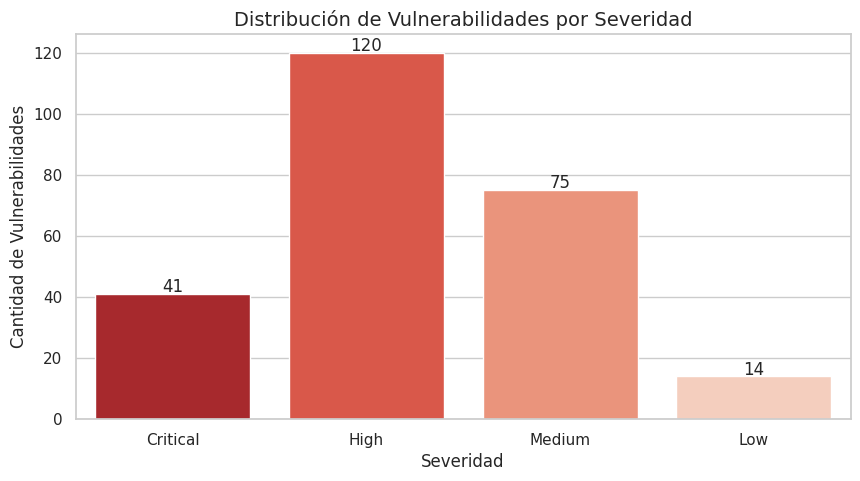

In [10]:
# Definir el orden lógico de las severidades
severity_order = ["Critical", "High", "Medium", "Low", "Negligible", "Unknown"]

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x="severity", order=[s for s in severity_order if s in df['severity'].unique()], palette="Reds_r")
plt.title("Distribución de Vulnerabilidades por Severidad", fontsize=14)
plt.xlabel("Severidad")
plt.ylabel("Cantidad de Vulnerabilidades")

# Añadir etiquetas a las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

## 3. Vulnerabilidades por Repositorio
Identificamos los repositorios con mayor cantidad de vulnerabilidades, para enfocar los esfuerzos de remediación.

/tmp/ipykernel_97724/2023730887.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=repo_counts.index, x=repo_counts.values, palette="viridis")


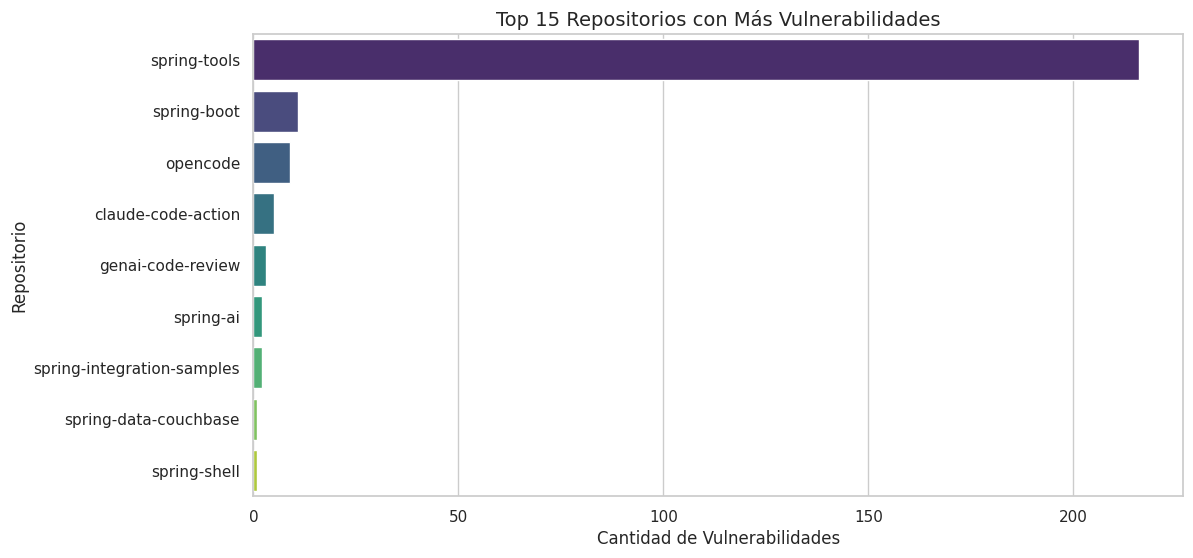

In [11]:
repo_counts = df['repository'].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(y=repo_counts.index, x=repo_counts.values, palette="viridis")
plt.title("Top 15 Repositorios con Más Vulnerabilidades", fontsize=14)
plt.xlabel("Cantidad de Vulnerabilidades")
plt.ylabel("Repositorio")
plt.show()

## 4. Paquetes Más Afectados
Análisis de las librerías o dependencias que introducen la mayor cantidad de riesgos (Top 10).

/tmp/ipykernel_97724/3216237419.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=pkg_counts.index, x=pkg_counts.values, palette="magma")


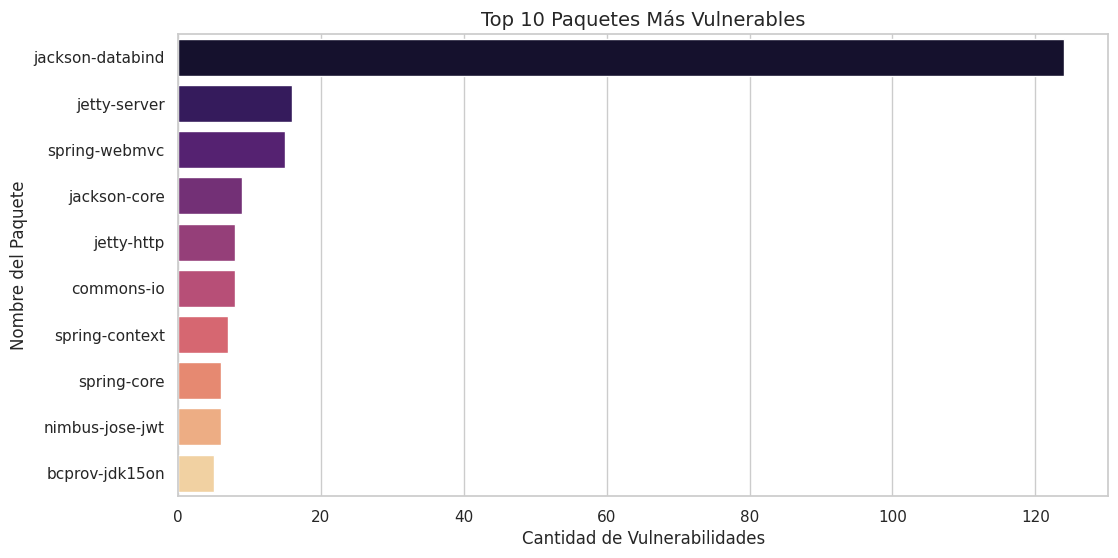

In [12]:
pkg_counts = df['package_name'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(y=pkg_counts.index, x=pkg_counts.values, palette="magma")
plt.title("Top 10 Paquetes Más Vulnerables", fontsize=14)
plt.xlabel("Cantidad de Vulnerabilidades")
plt.ylabel("Nombre del Paquete")
plt.show()

## 5. Resumen de Vulnerabilidades Críticas y Altas
Detalle de las vulnerabilidades más críticas para planificar acciones inmediatas.

In [13]:
critical_high_df = df[df['severity'].isin(['Critical', 'High'])]
summary = critical_high_df.groupby(['repository', 'package_name', 'severity']).size().reset_index(name='count')
summary.sort_values(by=['severity', 'count'], ascending=[True, False]).head(15)

,repository,package_name,severity,count
11,spring-tools,jackson-databind,Critical,38
19,spring-tools,spring-webmvc,Critical,2
8,spring-integration-samples,derby,Critical,1
12,spring-tools,jackson-databind,High,82
20,spring-tools,spring-webmvc,High,5
6,spring-boot,spring-core,High,4
9,spring-tools,commons-io,High,4
13,spring-tools,jetty-server,High,4
10,spring-tools,jackson-core,High,3
15,spring-tools,nimbus-jose-jwt,High,3


## Conclusiones
- Los repositorios críticos que requieren mayor atención inmediata.
- Las vulnerabilidades de tipo 'Critical' y 'High' se encuentran concentradas en ciertas dependencias.
- Este análisis proporciona una base sólida (Software Bill of Materials) y su estado de seguridad actual.